# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary.

**Goal:**
Identify the key vehicle attributes (mileage, age, brand/model, condition, etc.) that drive used car sale price, and build a model that predicts fair market price within an acceptable margin $7,100, so the dealership can price incoming vehicles.

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import datetime as dt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from warnings import filterwarnings
filterwarnings('ignore')
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.compose import make_column_transformer






In [ ]:
#import data
cars = pd.read_csv('/content/vehicles.csv')


In [ ]:
#what are the columns and counts
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

In [ ]:
#check head, tail, some samples
#cars.head()
#cars.tail()
cars.sample(5)

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
320730,7303484259,medford-ashland,34999,2017.0,toyota,tacoma,NaN,6 cylinders,gas,123235.0,clean,manual,5TFCZ5AN5HX102133,4wd,NaN,truck,NaN,or
186789,7315216212,boston,0,2018.0,gmc,sierra 1500 slt crew,like new,8 cylinders,gas,88.0,clean,automatic,3GTU2NEC8JG125448,4wd,full-size,pickup,silver,ma
349565,7312304309,myrtle beach,0,2018.0,chevrolet,silverado 1500,NaN,8 cylinders,gas,116174.0,clean,automatic,NaN,4wd,full-size,truck,white,sc
195961,7316884880,detroit metro,13995,2011.0,chevrolet,silverado,NaN,NaN,other,194000.0,clean,automatic,1GCRKSE3XBZ443321,NaN,NaN,pickup,black,mi
178003,7315752114,maine,10990,2013.0,toyota,matrix s awd,excellent,4 cylinders,gas,125000.0,clean,automatic,2T1LE4EE1DC022403,4wd,NaN,NaN,NaN,me


In [ ]:
# how many duplicate rows
cars.duplicated().sum()

np.int64(0)

In [ ]:
 #stats of data
 #Note: max price is very high (3 billion), min is 0
 #Other maxs and mins may have issues or be missing
cars.describe()

,id,price,year,odometer
count,4.268800e+05,4.268800e+05,425675.000000,4.224800e+05
mean,7.311487e+09,7.519903e+04,2011.235191,9.804333e+04
std,4.473170e+06,1.218228e+07,9.452120,2.138815e+05
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00
25%,7.308143e+09,5.900000e+03,2008.000000,3.770400e+04
50%,7.312621e+09,1.395000e+04,2013.000000,8.554800e+04
75%,7.315254e+09,2.648575e+04,2017.000000,1.335425e+05
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07


In [ ]:
#issues trying to plot the histogram
#what are the highest prices, some are billions
cars['price'].nlargest(10)

# Show the 100 highest-priced rows
cars.sort_values(by='price', ascending=False).head(10)

,price,year,manufacturer,condition,fuel,odometer,title_status,transmission,drive,type,paint_color,state
356716,3736928711,1999.0,toyota,fair,gas,211000.0,clean,automatic,4wd,NaN,green,tn
318592,3736928711,2007.0,toyota,excellent,gas,164000.0,clean,automatic,4wd,pickup,silver,or
91576,3024942282,2000.0,mercedes-benz,NaN,gas,100000.0,clean,automatic,NaN,NaN,NaN,de
257840,3024942282,2000.0,mercedes-benz,NaN,gas,100000.0,clean,automatic,NaN,NaN,NaN,nj
37410,3009548743,2021.0,chevrolet,NaN,gas,1000.0,clean,automatic,4wd,NaN,NaN,ca
184704,1410065407,1989.0,jeep,NaN,diesel,103000.0,clean,manual,NaN,SUV,NaN,md
153082,1234567890,2006.0,volvo,fair,other,200000.0,clean,manual,NaN,NaN,black,in
29386,1111111111,1999.0,ford,good,diesel,149000.0,clean,automatic,rwd,pickup,white,ca
37409,1111111111,2020.0,jeep,NaN,gas,1000.0,clean,automatic,4wd,NaN,NaN,ca
122470,987654321,1960.0,chevrolet,NaN,gas,9999999.0,clean,manual,NaN,NaN,NaN,ga


In [ ]:


# Look at all rows where price is over ____k
# Prices do not seem logically for most cars on this list
high_prices = cars[cars['price'] > 350000]
high_prices[['region', 'price', 'year', 'manufacturer', 'model']].sort_values(by='price', ascending=False)
#high_prices.shape

,region,price,year,manufacturer,model
356716,knoxville,3736928711,1999.0,toyota,4runner
318592,eugene,3736928711,2007.0,toyota,tundra
257840,south jersey,3024942282,2000.0,mercedes-benz,benz s430
91576,delaware,3024942282,2000.0,mercedes-benz,benz e320
37410,modesto,3009548743,2021.0,chevrolet,NaN
...,...,...,...,...,...
106361,orlando,516999,2016.0,NaN,Lambo Aventador SV Roadster
113357,south florida,470000,2016.0,NaN,hINO 268
360604,nashville,449500,2019.0,ferrari,488 gtb
133497,east idaho,425000,1993.0,jeep,wrangler


In [ ]:
#Check 95th, 99th, and 99.9th percentiles on price
#top 1% and min are outliers
cars['price'].describe(percentiles=[0.5, 0.9, 0.95, 0.99, 0.999])

,price
count,4.268800e+05
mean,7.519903e+04
std,1.218228e+07
min,0.000000e+00
50%,1.395000e+04
90%,3.759000e+04
95%,4.450000e+04
99%,6.699500e+04
99.9%,1.200000e+05
max,3.736929e+09


In [ ]:
# Look at all rows where price is under ____k or 0
low_prices = cars[cars['price'] <  1000]
low_prices[['region', 'price', 'year', 'manufacturer', 'model', 'condition', 'odometer']].sort_values(by='price', ascending=False)
#high_prices.shape

,region,price,year,manufacturer,model,condition,odometer
77665,denver,999,2003.0,chevrolet,venture ls,NaN,167000.0
318161,eugene,999,1996.0,honda,accord ex coupe,NaN,149609.0
318086,eugene,999,2005.0,buick,lesabre sedan,excellent,152856.0
369974,dallas / fort worth,999,2006.0,NaN,Nissas Xterra,good,174000.0
317806,eugene,999,1996.0,honda,accord ex coupe,NaN,149609.0
...,...,...,...,...,...,...,...
232980,charlotte,0,2013.0,honda,civic,NaN,192541.0
232961,charlotte,0,2012.0,honda,civic,NaN,166400.0
232960,charlotte,0,2003.0,ford,expedition,NaN,157931.0
232957,charlotte,0,2019.0,kia,soul,NaN,14904.0


Text(0.5, 1.0, 'Distribution of price')

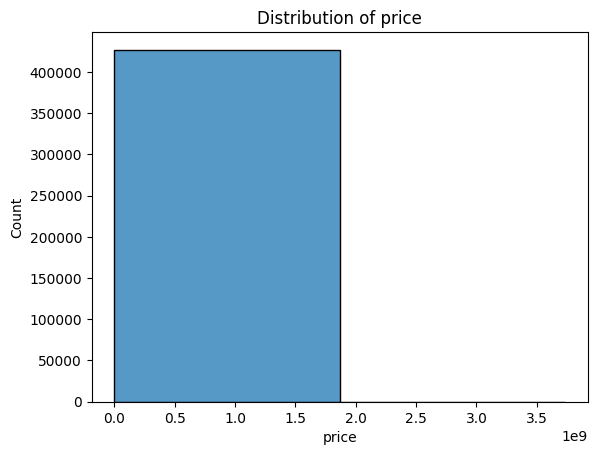

In [ ]:
#attempted to plot historgram, but couldn't because of outliers
#sns.histplot(cars['price'], bins = 2, kde=False)
#plt.title('Distribution of price')


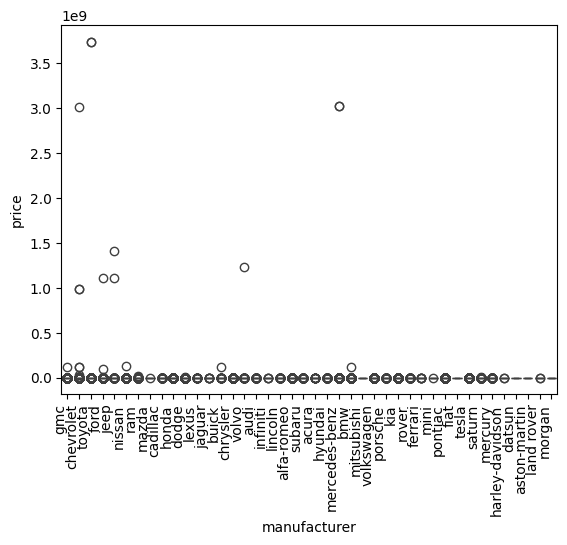

In [ ]:
#boxplot by manufacturer
#outliers are destroying the boxplot
sns.boxplot(data=cars, x='manufacturer', y='price')
plt.xticks(rotation=90, ha='right')
plt.show()

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`.

In [ ]:
#load data again to edit
cars = pd.read_csv('/content/vehicles.csv')


In [ ]:
#Started with 426,879 cars
#Delete irrelevant columns
cars = cars.drop(columns=['region','VIN', 'id', 'size' , 'model', 'cylinders'])

In [ ]:
#Delete cars that are missing any the year, manufacturer
#now 409228 cars
cars.dropna(subset=['year', 'manufacturer'], how='any', inplace=True)

In [ ]:
#Remove outliers PER MANUFACTURER using the IQR method
# IQR = Interquartile Range: the "normal middle 50%" of prices for THAT manufacturer
def remove_outliers_by_group(df, group_col, value_col, k=1.5):
    def filter_group(group):
        Q1 = group[value_col].quantile(0.25)   # 25th percentile price for this manufacturer
        Q3 = group[value_col].quantile(0.75)   # 75th percentile price for this manufacturer
        IQR = Q3 - Q1                           # the "typical spread" for this manufacturer
        lower = Q1 - k * IQR                    # anything below this is unusually cheap FOR THIS BRAND
        upper = Q3 + k * IQR                    # anything above this is unusually expensive FOR THIS BRAND
        return group[(group[value_col] >= lower) & (group[value_col] <= upper)]

    return df.groupby(group_col, group_keys=False).apply(filter_group)

cars_clean = remove_outliers_by_group(cars, 'manufacturer', 'price')
print(f"Rows before: {len(cars)}   Rows after: {len(cars_clean)}")

Rows before: 409228   Rows after: 402356


In [ ]:
#Get rid of extreme outliers low
#Keep only cars where the price above 99
#Now 368011 cars
cars_clean = cars_clean[cars_clean['price'] >= 100]

In [ ]:
#Get rid of extreme low years
#Keep only cars where year is 1990 or above
#Now 358755 cars
cars_clean = cars_clean[cars_clean['year'] > 1989]

In [ ]:
#Keep cars with more than 999 miles and less than 250000
#Now 345517 cars
cars_clean = cars_clean[cars_clean['odometer'] > 999]
cars_clean = cars_clean[cars_clean['odometer'] < 250000]

In [ ]:
#Check the percentiles, much more reasonable
cars_clean['price'].describe(percentiles=[.01, .10, 0.5, 0.9, 0.95, 0.99, 0.999])

,price
count,345517.000000
mean,18458.439020
std,13190.571866
min,100.000000
1%,350.000000
10%,4000.000000
50%,15750.000000
90%,36990.000000
95%,42590.000000
99%,55748.000000


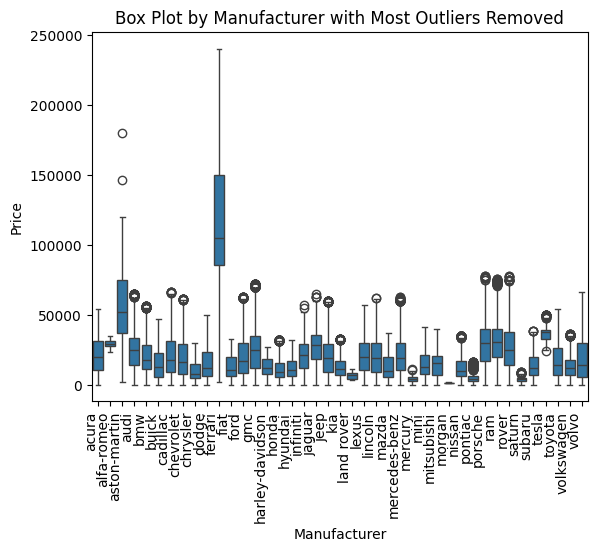

In [ ]:
#boxplot with outliers removed
sns.boxplot(data=cars_clean, x='manufacturer', y='price')
plt.xticks(rotation=90, ha='right')
plt.title('Box Plot by Manufacturer with Most Outliers Removed')
plt.xlabel('Manufacturer')
plt.ylabel('Price')
plt.show()

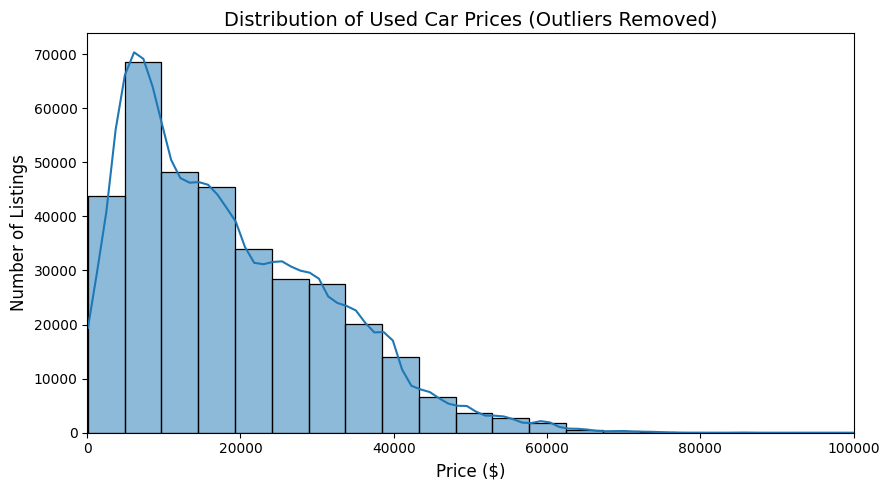

In [ ]:
#Histogram of car prices with cleaned data
plt.figure(figsize=(9, 5))
sns.histplot(cars_clean['price'], bins=50, kde=True)  # 50 bins reveals shape; kde adds a smooth trend line

plt.title('Distribution of Used Car Prices (Outliers Removed)', fontsize=14)
plt.xlabel('Price ($)', fontsize=12)
plt.ylabel('Number of Listings', fontsize=12)
plt.xlim(0,100000)
plt.tight_layout()
plt.show()

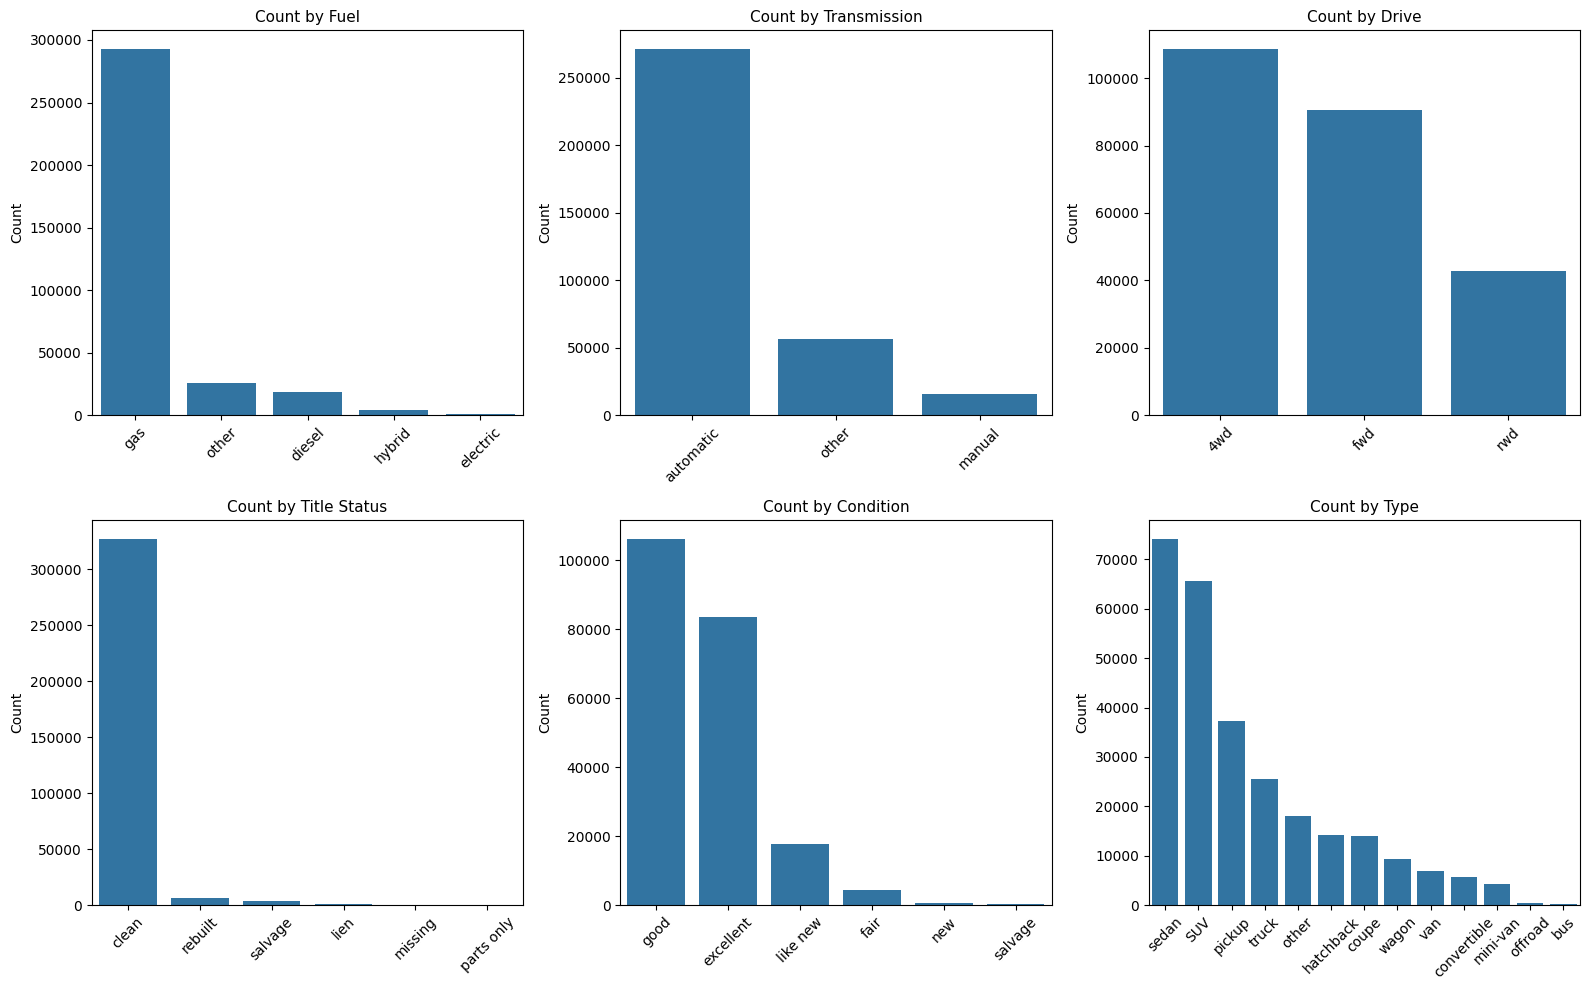

In [ ]:
#Subplots of categories
cat_features = ['fuel', 'transmission', 'drive', 'title_status', 'condition', 'type']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))  # 2 rows x 3 cols = 6 panels
axes = axes.flatten()  # turns the 2D grid of axes into a simple list to loop over

for i, col in enumerate(cat_features):
    # order=... sorts bars by frequency so the most common category is always first —
    # much easier to read than alphabetical or random order
    order = cars_clean[col].value_counts().index
    sns.countplot(data=cars_clean, x=col, order=order, ax=axes[i])

    axes[i].set_title(f'Count by {col.replace("_", " ").title()}', fontsize=11)
    axes[i].set_xlabel('')  # the subplot title already says what this is, so skip redundant label
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)  # long category names need rotation to stay legible

plt.tight_layout()
plt.show()

#Transform the data into floats and integers





In [ ]:
#check the data types for integers
cars_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 345517 entries, 98 to 426876
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   price         345517 non-null  int64  
 1   year          345517 non-null  float64
 2   manufacturer  345517 non-null  object 
 3   condition     212716 non-null  object 
 4   fuel          343638 non-null  object 
 5   odometer      345517 non-null  float64
 6   title_status  339123 non-null  object 
 7   transmission  344152 non-null  object 
 8   drive         242152 non-null  object 
 9   type          275843 non-null  object 
 10  paint_color   245669 non-null  object 
 11  state         345517 non-null  object 
dtypes: float64(2), int64(1), object(9)
memory usage: 34.3+ MB


In [ ]:
#Fill NaNs with "unknown"
cat_cols = ['condition', 'fuel', 'title_status', 'transmission', 'drive', 'type', 'paint_color']

cars_clean[cat_cols] = cars_clean[cat_cols].fillna('unknown')

In [ ]:
#make a copy to edit and transform the columns, in case a mistake is made
cars_transformed = cars_clean.copy()

In [ ]:
#Assign values to conditions
#Make unknown 2 as good appears the most
condition_map = {
    'new': 5,
    'like new': 4,
    'excellent': 3,
    'good': 2,
    'unknown': 2,
    'fair': 1,
    'salvage': 0
}

#Apply the mapping to create a new numerical column
cars_transformed ['condition_ranked'] = cars_transformed ['condition'].map(condition_map)

In [ ]:
#drop condition column
cars_transformed = cars_transformed.drop(columns=['condition'])

In [ ]:
#Assign 1 to clean title and 0 to the rest
title_map = {
    'clean' : 1
}

#Apply the mapping to create a new numerical column
cars_transformed['title_clean'] = cars_transformed['title_status'].map(title_map).fillna(0).astype(int)

In [ ]:
#Drop orginal title column
cars_transformed = cars_transformed.drop(columns=['title_status'])

In [ ]:
#Assign 1 to automatic and 0 to the rest
transmission_map = {
    'automatic' : 1
}

#Apply the mapping to create a new numerical column
cars_transformed['transmission_automatic'] = cars_transformed['transmission'].map(transmission_map).fillna(0).astype(int)

In [ ]:
#Drop orginal transmission column
cars_transformed = cars_transformed.drop(columns=['transmission'])

In [ ]:
#Assign 1 to gas and 0 to the rest
gas_map = {
    'gas' : 1
}

#Apply the mapping to create a new numerical column
cars_transformed['fuel_gas'] = cars_transformed['fuel'].map(gas_map).fillna(0).astype(int)

In [ ]:
#drop orginal fuel column
cars_transformed = cars_transformed.drop(columns=['fuel'])

In [ ]:
cars_transformed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 345517 entries, 98 to 426876
Data columns (total 12 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   price                   345517 non-null  int64  
 1   year                    345517 non-null  float64
 2   manufacturer            345517 non-null  object 
 3   odometer                345517 non-null  float64
 4   drive                   345517 non-null  object 
 5   type                    345517 non-null  object 
 6   paint_color             345517 non-null  object 
 7   state                   345517 non-null  object 
 8   condition_ranked        345517 non-null  int64  
 9   title_clean             345517 non-null  int64  
 10  transmission_automatic  345517 non-null  int64  
 11  fuel_gas                345517 non-null  int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 34.3+ MB


#Modeling



# Encode the data using OneHotEncoder for all other columns

In [ ]:

#grab only the categorical (object/category) columns from cars
cat_cols = cars_transformed.select_dtypes(include=['object', 'category']).columns

#fit_transform learns the categories AND applies the encoding in one step
#drop='first' avoids the dummy variable trap (redundant column)
#sparse_output=False returns a regular array instead of a sparse matrix
#handle_unknown='ignore' prevents errors if new/unseen categories show up later
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
encoded_array = ohe.fit_transform(cars_transformed[cat_cols])

#get_feature_names_out() gives readable names like 'fuel_diesel' instead of x0_diesel
encoded_df = pd.DataFrame(
    encoded_array,
    columns=ohe.get_feature_names_out(cat_cols),
    index=cars_transformed.index  # keep original index so concat aligns rows correctly
)

#drop the original categorical columns, then attach the new encoded ones
cars_encoded = pd.concat([cars_transformed.drop(columns=cat_cols), encoded_df], axis=1)

cars_encoded.head()

,price,year,odometer,condition_ranked,title_clean,transmission_automatic,fuel_gas,manufacturer_alfa-romeo,manufacturer_aston-martin,manufacturer_audi,...,state_sd,state_tn,state_tx,state_ut,state_va,state_vt,state_wa,state_wi,state_wv,state_wy
98,20590,2013.0,77087.0,2,1,0,1,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
136,39990,2020.0,1237.0,2,1,0,1,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
160,28000,2018.0,55000.0,3,1,1,1,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
272,5980,2005.0,179721.0,2,0,1,1,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
354,6000,2011.0,197331.0,2,1,1,1,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


**A note on one-hot encoding and "baseline" categories**

When a categorical feature like `type` gets one-hot encoded with `drop='first'`, one category
(alphabetically first — in our case, SUV) doesn't get its own column. Instead, that category
becomes the *reference point* the model measures every other category against. A row where
every `type_` column is 0 is implicitly an SUV. This means every other `type_X` coefficient in
our regression should be read as "compared to an SUV," not as a standalone dollar value.

In [ ]:
#Calculate correlations with price
price_corr = cars_encoded.corr(numeric_only=True)['price']

#Filter for correlations above 0.15
strong_correlations = price_corr[price_corr.abs() > 0.15].sort_values(ascending=False)

print(strong_correlations)



price                     1.000000
year                      0.580748
type_pickup               0.256601
manufacturer_ram          0.194610
type_truck                0.168379
type_other                0.154405
type_sedan               -0.178592
transmission_automatic   -0.259125
drive_fwd                -0.264819
fuel_gas                 -0.297622
odometer                 -0.560468
Name: price, dtype: float64


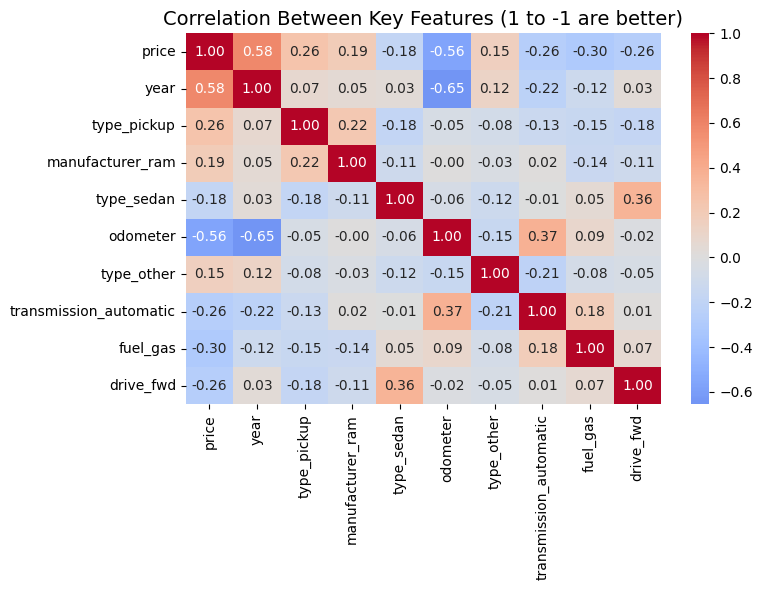

In [ ]:
#Heatmap
#Specific columns to check
selected_cols = ['price', 'year', 'type_pickup', 'manufacturer_ram', 'type_sedan', 'odometer',
                 'type_other', 'transmission_automatic', 'fuel_gas', 'drive_fwd']

#Correlate only within that subset
corr_matrix = cars_encoded[selected_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Between Key Features (1 to -1 are better)', fontsize=14)
plt.tight_layout()
plt.show()

# **Why RMSE is our primary evaluation metric**

We use RMSE (Root Mean Squared Error) to judge how good our model is, for two simple reasons:

- **It's measured in dollars, just like price.** This means we can say something simple and
  useful: *"our model is usually off by about \$7,100."*

- **It punishes big mistakes more than small ones.** Picture two scenarios:
  - Scenario A: the model is \$20,000 wrong on **one** car.
  - Scenario B: the model is \$200 wrong on **ten** different cars.
  
  Both add up to a similar total error — but Scenario A is a much bigger problem. One giant mispricing can lose real money or trust, while ten small misses
  barely matter. RMSE is built to treat the big miss as the worse outcome, which matches
  how pricing mistakes actually play out in real life.

**A second number, for balance:** we also report **MAE** (Mean Absolute Error) alongside
RMSE. Think of MAE as the "typical" mistake size, without letting a few extreme misses —
like the Ram and luxury car issues we found later — pull the number around too much.
Reporting both gives us a fuller picture: RMSE tells us about our worst-case risk, and MAE
tells us what to expect on a normal day.

# Train, test, split the data to be used on different models

In [ ]:
#train, test, split the data
X = cars_encoded.drop('price', axis=1)
y = cars_encoded['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression Model

In [ ]:
#Linear Regression Model
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
preds = lin_reg.predict(X_test)

#Calculate MSE, MAE, RMSE
mse  = mean_squared_error(y_test, preds)
mae  = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mse)
print(f'MSE: {mse:.2f}   MAE: {mae:.2f}   RMSE: {rmse:.2f}')
print('-----')

#Check 1: compare to a baseline that always predicts the mean price.
#Model beats the baseline
baseline_preds = np.full_like(y_test, y_train.mean(), dtype=float)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_preds))
print('Baseline RMSE (always guess the mean):', baseline_rmse)
print('-----')

# Check 2: do the coefficient signs make business sense?
#coefs = pd.Series(lin_reg.coef_, index=X.columns).sort_values()
#print(coefs)


MSE: 60025733.15   MAE: 5527.86   RMSE: 7747.63
-----
Baseline RMSE (always guess the mean): 13167.151801914517
-----
Top 10 features that INCREASE predicted price:
manufacturer_ferrari         97716.652575
manufacturer_aston-martin    33652.090859
manufacturer_porsche          9862.311969
type_truck                    6606.117258
manufacturer_tesla            6332.542221
type_pickup                   5410.112841
type_offroad                  5392.351641
title_clean                   4428.973277
type_other                    4132.977231
manufacturer_rover            4025.564669
dtype: float64

Top 10 features that DECREASE predicted price:
manufacturer_subaru             -4855.384723
fuel_gas                        -5534.435086
manufacturer_nissan             -5811.940757
manufacturer_hyundai            -5930.204446
drive_fwd                       -6324.082061
manufacturer_kia                -6663.409360
manufacturer_mitsubishi         -7882.920807
manufacturer_harley-davidson    -8186

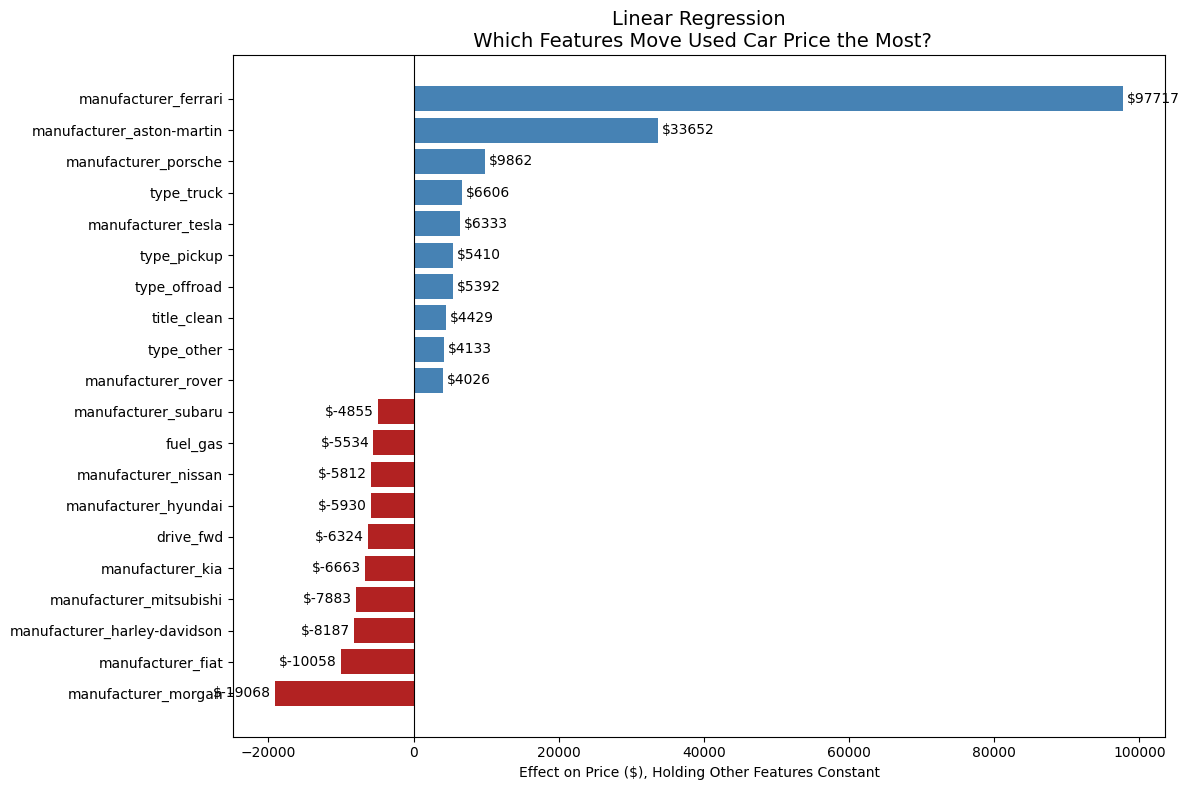

In [ ]:
#Coefficeints of categories
coefs = pd.Series(lin_reg.coef_, index=X.columns).sort_values(ascending=False)

# Show the 10 features that push price up the most, and the 10 that push it down the most
top_positive = coefs.head(10)
top_negative = coefs.tail(10)

#Linear Regression Chart Features Affecting Price
fig, ax = plt.subplots(figsize=(12, 8))
top_coefs = pd.concat([top_positive, top_negative]).sort_values()  # combine and sort for a clean bar chart

colors = ['firebrick' if v < 0 else 'steelblue' for v in top_coefs.values]  # red = lowers price, blue = raises price
bars = ax.barh(top_coefs.index, top_coefs.values, color=colors)  # capture the bar container so we can label it

ax.set_title('Linear Regression\n Which Features Move Used Car Price the Most?', fontsize=14)
ax.set_xlabel('Effect on Price ($), Holding Other Features Constant')
ax.axvline(0, color='black', linewidth=0.8)  # zero line makes direction obvious at a glance

ax.bar_label(bars, fmt='$%.0f', padding=3)
plt.tight_layout()
plt.show()

### Explanation of Coefficients Above
**Interpreting the coefficients**

Coefficient sign shows direction: positive raises predicted price, negative lowers it, holding all else equal. Categorical features were one-hot encoded with a reference category dropped (SUV for `type`), so each coefficient reads as "vs. the reference category, holding all else equal":

**Positive coefficients (raise predicted price):**
- **`type_pickup` (\$6,606):** a pickup truck is predicted to cost about \$6,606 more than an SUV.
- **`title_clean` (\$4,429):** a car with a clean title is predicted to cost about \$4,429 more than a car with a non-clean title of any kind (salvage, rebuilt, lien, missing, or parts-only, all grouped together).

**Negative coefficients (lower predicted price):**
- **`drive_fwd` (-\$6,324):** holding all else equal, a front-wheel-drive car is predicted to cost about \$6,324 *less* than the reference drive type.
- **`fuel_gas` (-\$5,534):** holding all else equal, a gas-powered car is predicted to cost about \$5,534 *less* than the reference fuel type.

# Ridge Regression

In [ ]:
#Ridge Regression
#Produced the same RMSE as Linear, not a better model
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge()),
])

#alpha = penalty strength
#GridSearchCV finds the best one via cross-validation
param_grid = {'ridge__alpha': [0.01, 0.1, 1, 10, 100]}
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error')
grid.fit(X_train, y_train)

#find the best model
best_model = grid.best_estimator_
preds = best_model.predict(X_test)

#Calculate MSE, MAE, RMSE
mse  = mean_squared_error(y_test, preds)
mae  = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mse)
print(f'Best alpha: {grid.best_params_}')
print('-----')
print(f'MSE: {mse:.2f}   MAE: {mae:.2f}   RMSE: {rmse:.2f}')
print('-----')

# --- CHECKS ---
# Check: did tuning alpha actually help? Compare against alpha=0 (no penalty,
# equivalent to plain linear regression). If tuned RMSE isn't better, the
# penalty isn't adding value for this particular dataset.

# fit=fit ONCE on X_train (learn mean/std from training data only)
scaler = StandardScaler().fit(X_train)

# transform (not fit_transform) on both — test data must use train's scaling
X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)

plain_ridge = Ridge(alpha=0).fit(X_train_scaled, y_train)
plain_preds = plain_ridge.predict(X_test_scaled)
print('Plain (alpha=0) RMSE:', np.sqrt(mean_squared_error(y_test, plain_preds)))

Best alpha: {'ridge__alpha': 10}
-----
MSE: 60025714.61   MAE: 5527.85   RMSE: 7747.63
-----
Plain (alpha=0) RMSE: 7747.627581830491


# Polynomial Models

# Polynomial Degree 2 with Linear Regression

In [ ]:
#Use top columns with correlation of .15 or better
poly_cols = [ 'year','type_pickup', 'type_truck', 'manufacturer_ram','type_other', 'type_sedan','odometer', 'transmission_automatic', 'drive_fwd', 'fuel_gas']

#Polynomial with degree 2
preprocessor = make_column_transformer(
    (PolynomialFeatures(degree=2, include_bias=False), poly_cols),
    remainder='passthrough'
)

pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('lin_reg', LinearRegression()),
])

pipe.fit(X_train, y_train)
preds = pipe.predict(X_test)

#Calculate MSE, MAE, RMSE
mse  = mean_squared_error(y_test, preds)
mae  = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mse)
print(f'MSE: {mse:.2f}   MAE: {mae:.2f}   RMSE: {rmse:.2f}')
print('-----')

# --- CHECKS ---
# Check 1: beat the baseline that always predicts the mean price.
baseline_preds = np.full_like(y_test, y_train.mean(), dtype=float)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_preds))
print('Baseline RMSE (always guess the mean):', baseline_rmse)
print('-----')

# Check 2: compare against plain linear regression (no poly features).
# If poly RMSE isn't meaningfully better, the extra complexity isn't earning its keep.
plain_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lin_reg', LinearRegression()),
])
plain_pipe.fit(X_train, y_train)
plain_preds = plain_pipe.predict(X_test)
plain_rmse = np.sqrt(mean_squared_error(y_test, plain_preds))
print('Plain linear regression RMSE (no poly features):', plain_rmse)
print('-----')

# Check 3: train vs test RMSE — a big gap (train much lower than test)
# is a red flag for overfitting, which poly features can easily cause.
train_preds = pipe.predict(X_train)
train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
print(f'Train RMSE: {train_rmse:.2f}   Test RMSE: {rmse:.2f}')
print('-----')

# Check 4: look at the coefficients, now with proper feature names
# get_feature_names_out() pulls names through the whole pipeline
# (so poly terms show up as e.g. 'mileage^2', 'mileage horsepower', etc.)
feature_names = pipe.named_steps['preprocessor'].get_feature_names_out()
coefs = pd.Series(pipe.named_steps['lin_reg'].coef_, index=feature_names).sort_values()
#print('Coefficients: ')
#print(coefs)

MSE: 52069950.76   MAE: 4942.59   RMSE: 7215.95
-----
Baseline RMSE (always guess the mean): 13167.151801914517
-----
Plain linear regression RMSE (no poly features): 7747.627581830492
-----
Train RMSE: 7206.30   Test RMSE: 7215.95
-----


# Polynomial Degree 2 with Ridge Regression

In [ ]:
#pick out just the numeric columns you want squared/interacted
poly_cols = [ 'year','type_pickup', 'type_truck', 'manufacturer_ram','type_other', 'type_sedan','odometer', 'transmission_automatic', 'drive_fwd', 'fuel_gas']

preprocessor = make_column_transformer(
    (PolynomialFeatures(degree=2, include_bias=False), poly_cols),
    remainder='passthrough'
)

pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('ridge_reg', Ridge()),
])

pipe.fit(X_train, y_train)
preds = pipe.predict(X_test)

# --- RESULTS: MSE, MAE, RMSE ---
mse  = mean_squared_error(y_test, preds)
mae  = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mse)
print(f'MSE: {mse:.2f}   MAE: {mae:.2f}   RMSE: {rmse:.2f}')
print('-----')

# --- CHECKS ---
# Check 1: beat the baseline that always predicts the mean price.
baseline_preds = np.full_like(y_test, y_train.mean(), dtype=float)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_preds))
print('Baseline RMSE (always guess the mean):', baseline_rmse)
print('-----')

# Check 2: compare against plain linear regression (no poly features).
# If poly RMSE isn't meaningfully better, the extra complexity isn't earning its keep.
plain_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge_reg', LinearRegression()),
])
plain_pipe.fit(X_train, y_train)
plain_preds = plain_pipe.predict(X_test)
plain_rmse = np.sqrt(mean_squared_error(y_test, plain_preds))
print('Plain linear regression RMSE (no poly features):', plain_rmse)
print('-----')

# Check 3: train vs test RMSE — a big gap (train much lower than test)
# is a red flag for overfitting, which poly features can easily cause.
train_preds = pipe.predict(X_train)
train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
print(f'Train RMSE: {train_rmse:.2f}   Test RMSE: {rmse:.2f}')
print('-----')

# Check 4: look at the coefficients, now with proper feature names
# get_feature_names_out() pulls names through the whole pipeline
# (so poly terms show up as e.g. 'mileage^2', 'mileage horsepower', etc.)
feature_names = pipe.named_steps['preprocessor'].get_feature_names_out()
coefs = pd.Series(pipe.named_steps['ridge_reg'].coef_, index=feature_names).sort_values()
#print('Coefficients: ')
#print(coefs)

MSE: 53195341.59   MAE: 5020.79   RMSE: 7293.51
-----
Baseline RMSE (always guess the mean): 13167.151801914517
-----
Plain linear regression RMSE (no poly features): 7747.627581830492
-----
Train RMSE: 7280.61   Test RMSE: 7293.51
-----


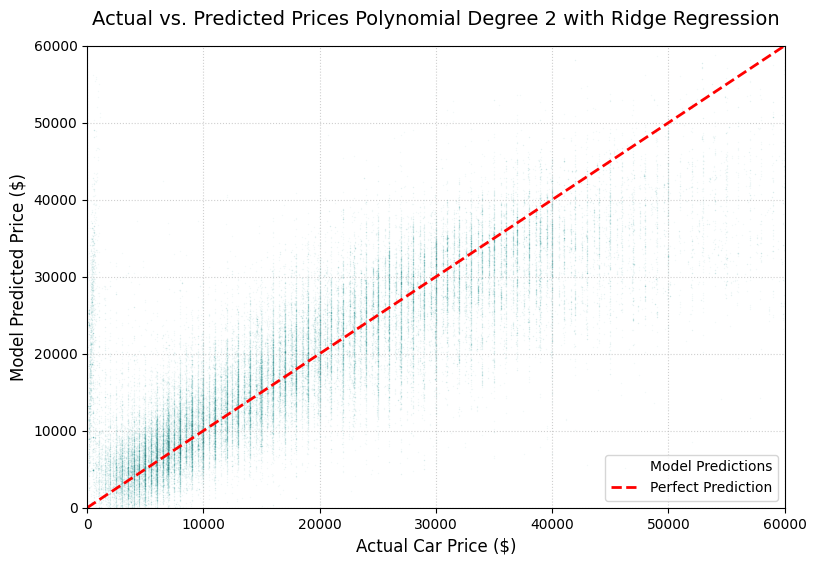

In [ ]:
plt.figure(figsize=(9, 6))

# s=1 makes the dots tiny; alpha=0.05 makes them highly translucent
sns.scatterplot(x=y_test, y=preds, alpha=0.05, s=1, color='teal', label='Model Predictions')

perfect_line = np.linspace(0, 60000, 100)
plt.plot(perfect_line, perfect_line, color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.xlim(0, 60000)
plt.ylim(0, 60000)
plt.title('Actual vs. Predicted Prices (Polynomial Degree 2 with Ridge Regression)', fontsize=14, pad=15)
plt.xlabel('Actual Car Price ($)', fontsize=12)
plt.ylabel('Model Predicted Price ($)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# Polynomial Degree 3 with Linear Regression
# The Best Model

In [ ]:
# pick out just the numeric columns you want squared/interacted
poly_cols = [ 'year','type_pickup', 'type_truck', 'manufacturer_ram','type_sedan','odometer', 'transmission_automatic', 'drive_fwd', 'fuel_gas']

preprocessor = make_column_transformer(
    (PolynomialFeatures(degree=3, include_bias=False), poly_cols),
    remainder='passthrough'
)

pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('lin_reg', LinearRegression()),
])

pipe.fit(X_train, y_train)
preds = pipe.predict(X_test)

#Calculate MSE, MAE, RMSE
mse  = mean_squared_error(y_test, preds)
mae  = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mse)
print(f'MSE: {mse:.2f}   MAE: {mae:.2f}   RMSE: {rmse:.2f}')
print('-----')

# --- CHECKS ---
# Check 1: beat the baseline that always predicts the mean price.
baseline_preds = np.full_like(y_test, y_train.mean(), dtype=float)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_preds))
print('Baseline RMSE (always guess the mean):', baseline_rmse)
print('-----')

# Check 2: compare against plain linear regression (no poly features).
# If poly RMSE isn't meaningfully better, the extra complexity isn't earning its keep.
plain_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lin_reg', LinearRegression()),
])
plain_pipe.fit(X_train, y_train)
plain_preds = plain_pipe.predict(X_test)
plain_rmse = np.sqrt(mean_squared_error(y_test, plain_preds))
print('Plain linear regression RMSE (no poly features):', plain_rmse)
print('-----')

# Check 3: train vs test RMSE — a big gap (train much lower than test)
# is a red flag for overfitting, which poly features can easily cause.
train_preds = pipe.predict(X_train)
train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
print(f'Train RMSE: {train_rmse:.2f}   Test RMSE: {rmse:.2f}')
print('-----')

# Check 4: look at the coefficients, now with proper feature names
# get_feature_names_out() pulls names through the whole pipeline
# (so poly terms show up as e.g. 'mileage^2', 'mileage horsepower', etc.)
feature_names = pipe.named_steps['preprocessor'].get_feature_names_out()
coefs = pd.Series(pipe.named_steps['lin_reg'].coef_, index=feature_names).sort_values()
#print("Coefficients: ")
#print(coefs)

MSE: 50835906.50   MAE: 4835.30   RMSE: 7129.93
-----
Baseline RMSE (always guess the mean): 13167.151801914517
-----
Plain linear regression RMSE (no poly features): 7747.627581830492
-----
Train RMSE: 7087.89   Test RMSE: 7129.93
-----


**Findings: Our Best Model**

Our model guesses a car's price and is usually off by about \$4,800 to \$7,100 — not exact,
but close enough to be genuinely useful.

- **Way better than a random guess:** if we just guessed "the average price" for every
  car, we'd be off by about \$13,200. This model cuts that error almost in half.
- **Better than our simpler model too:** a basic version of our model was off by about
  \$7,700. Adding more detail to the model improved that to \$7,100 — about 8% better.
- **It's not just memorizing, it actually learned something:** we tested the model on
  cars it had never seen before, and it did almost exactly as well as on the cars it
  studied. That's a good sign. If a model does great on cars it already knows but badly on
  new ones, that means it just memorized the answers instead of learning the pattern,
  kind of like memorizing test answers instead of understanding the material. Our model
  passed that test.

**What this means in real life:** if the model says a car is worth \$15,000, the actual
price will probably land somewhere between \$10,000 and \$20,000. That's not precise enough
to set an exact price tag, but a decent start.

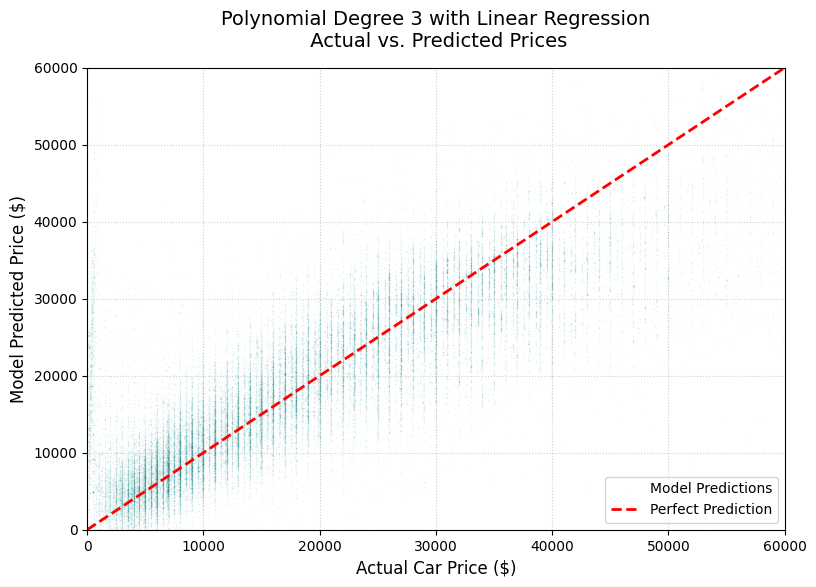

In [ ]:

plt.figure(figsize=(9, 6))

# s=1 makes the dots tiny; alpha=0.05 makes them highly translucent
sns.scatterplot(x=y_test, y=preds, alpha=0.05, s=1, color='teal', label='Model Predictions')

perfect_line = np.linspace(0, 60000, 100)
plt.plot(perfect_line, perfect_line, color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.xlim(0, 60000)
plt.ylim(0, 60000)
plt.title('Polynomial Degree 3 with Linear Regression\n Actual vs. Predicted Prices', fontsize=14, pad=15)
plt.xlabel('Actual Car Price ($)', fontsize=12)
plt.ylabel('Model Predicted Price ($)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# Find the major misses of predictions within our top model

In [ ]:
# --- Helper: turn a group of one-hot columns back into one readable column ---
# e.g. columns 'manufacturer_ford', 'manufacturer_toyota', 'manufacturer_ram'...
# get collapsed back into a single 'manufacturer' column with the actual name
def undummy(df, prefix):
    # grab every column that starts with the prefix (e.g. all 'manufacturer_' columns)
    cols = [c for c in df.columns if c.startswith(prefix + '_')]
    # for each row, find WHICH of those columns is 1, and strip the prefix back off
    # idxmax() returns the column name with the highest value (i.e. the '1' column)
    return df[cols].idxmax(axis=1).str.replace(prefix + '_', '', regex=False)

# --- Rebuild a small readable lookup table, indexed the same as X_test ---
df_check = pd.DataFrame(index=X_test.index)
df_check['manufacturer'] = undummy(cars_encoded.loc[X_test.index], 'manufacturer')
df_check['type']         = undummy(cars_encoded.loc[X_test.index], 'type')
df_check['odometer']     = cars_encoded.loc[X_test.index, 'odometer']  # already numeric, no decoding needed

df_check['actual']    = y_test
df_check['predicted'] = preds
df_check['abs_error'] = np.abs(df_check['actual'] - df_check['predicted'])

# --- Worst individual predictions, now with real car info ---
worst = df_check.sort_values('abs_error', ascending=False).head(10)

# --- Look for a PATTERN across your worst predictions ---
worst_50 = df_check.sort_values('abs_error', ascending=False).head(50)

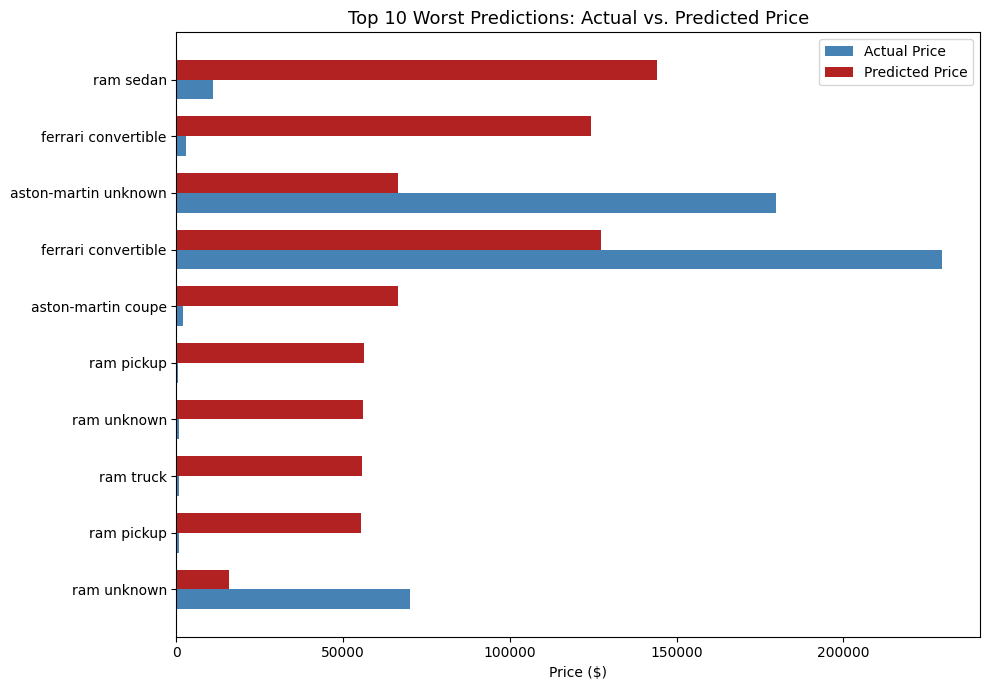

In [ ]:
#Top 10 Worst Predictions
#Build labels that identify each car (manufacturer + type) since row index alone isn't readable
worst_labeled = worst.copy()
worst_labeled['label'] = worst_labeled['manufacturer'] + ' ' + worst_labeled['type']

#Sort so the single worst miss is at the top of the chart, not the bottom
worst_labeled = worst_labeled.sort_values('abs_error', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))

y_pos = np.arange(len(worst_labeled))
bar_height = 0.35

# Two bars per car: one for actual price, one for predicted price
ax.barh(y_pos - bar_height/2, worst_labeled['actual'], height=bar_height,
        label='Actual Price', color='steelblue')
ax.barh(y_pos + bar_height/2, worst_labeled['predicted'], height=bar_height,
        label='Predicted Price', color='firebrick')

ax.set_yticks(y_pos)
ax.set_yticklabels(worst_labeled['label'])
ax.set_xlabel('Price ($)')
ax.set_title('Top 10 Worst Predictions: Actual vs. Predicted Price', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

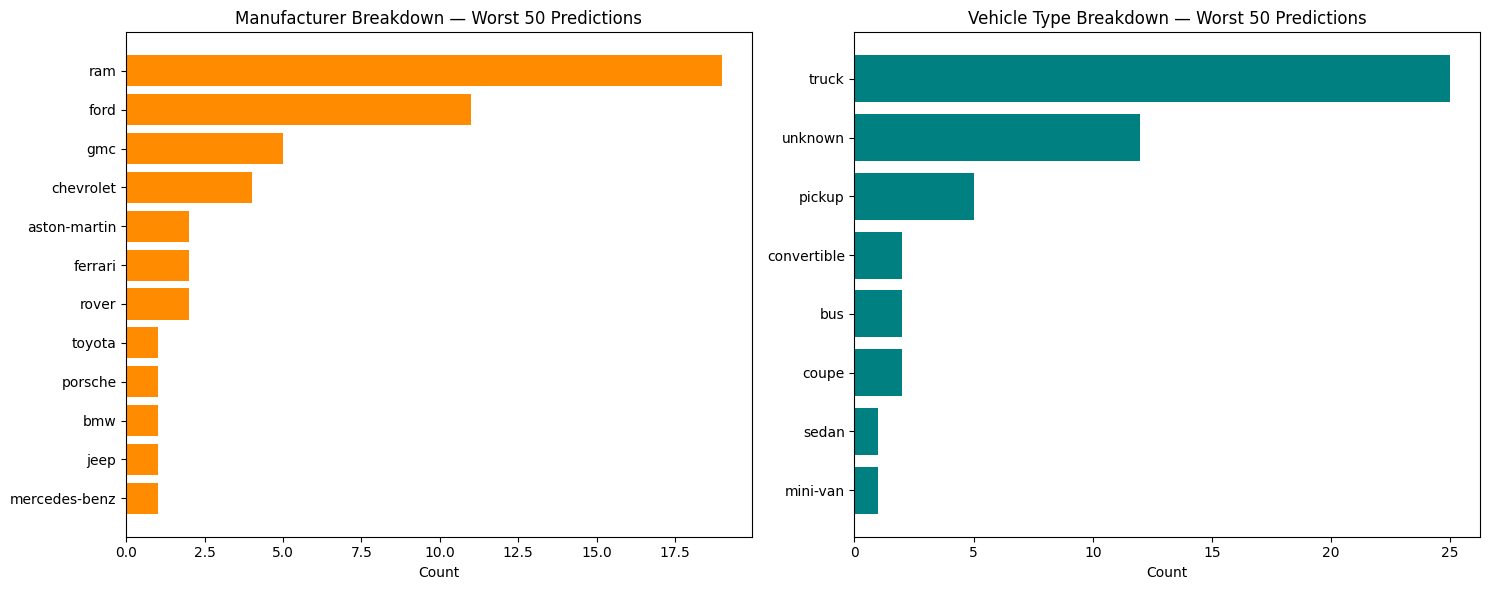

In [ ]:
#Worst Predictions by Manufacturer and Type
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
# Left panel: which manufacturers show up most among the worst predictions
manu_counts = worst_50['manufacturer'].value_counts()
axes[0].barh(manu_counts.index, manu_counts.values, color='darkorange')
axes[0].invert_yaxis()  # puts the most frequent manufacturer at the top, easier to scan
axes[0].set_title('Manufacturer Breakdown — Worst 50 Predictions', fontsize=12)
axes[0].set_xlabel('Count')

# Right panel: which vehicle types show up most among the worst predictions
type_counts = worst_50['type'].value_counts()
axes[1].barh(type_counts.index, type_counts.values, color='teal')
axes[1].invert_yaxis()
axes[1].set_title('Vehicle Type Breakdown — Worst 50 Predictions', fontsize=12)
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

**Notes on the Worst Predictions**

The worst individual predictions reveal two distinct, opposite failure patterns rather
than random noise:

**1. Ram vehicles are systematically over-predicted.** Ram accounts for 19 of the worst 50
predictions (38%) — by far the largest single manufacturer, more than double the next
closest (Ford, 11). In nearly every one of our 10 worst individual misses, Ram vehicles
show an actual sale price near \$0 while the model predicted several thousand dollars. This
is a strong, one-directional pattern rather than scattered error, which points to a likely
data quality issue: these may be incomplete listings, placeholder/error prices (\$1 or \$0
entries), or damaged/parts-only vehicles that weren't fully caught by our title-status or
price-floor cleaning steps. This is worth investigating directly in the raw data before
trusting the model's Ram-specific predictions.

**2. Rare luxury vehicles (Ferrari, Aston-Martin) are under-predicted.** These show the
opposite issue — high actual sale prices, but the model predicts substantially lower. This
likely reflects a data volume problem rather than a data quality one: exotic/luxury brands
are rare in a 426K-row dataset dominated by mainstream vehicles, so the model has too few
examples to learn their true price premium and defaults toward more typical price ranges
for similar body styles.

**Practical takeaway:** this model is best trusted for common vehicles (sedans, SUVs,
mainstream trucks) and should not be relied on for pricing exotic/luxury vehicles or
flagged Ram listings without a manual data quality check first.

### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

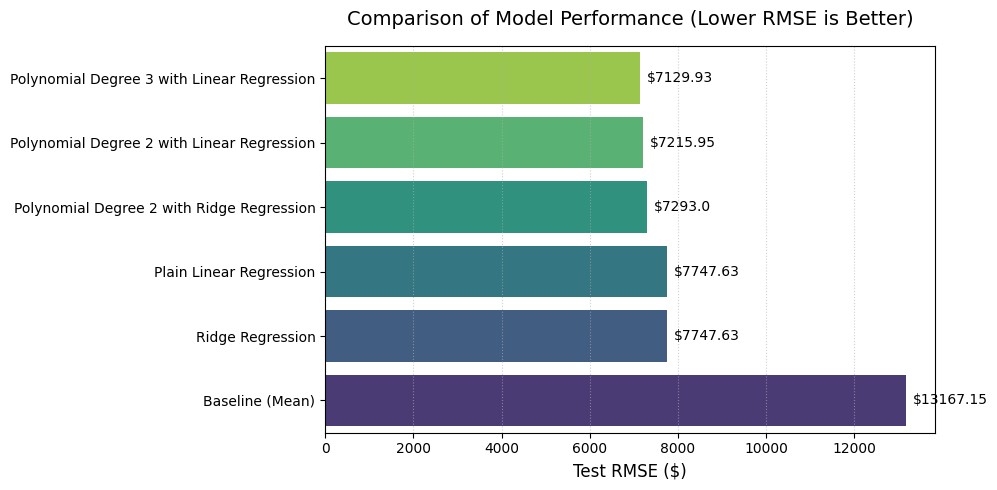

In [ ]:
#Dictionary storing the Test RMSE values you've gathered so far
model_data = {
    'Model': [
        'Baseline (Mean)',
        'Plain Linear Regression',
        'Ridge Regression',
        'Polynomial Degree 2 with Linear Regression',
        'Polynomial Degree 2 with Ridge Regression',
        'Polynomial Degree 3 with Linear Regression'
    ],
    # RMSE from models
    'Test RMSE': [13167.15, 7747.63, 7747.63, 7215.95, 7293, 7129.93]
}

#Convert to a DataFrame and sort so the best model is at the top
df_models = pd.DataFrame(model_data).sort_values(by='Test RMSE', ascending=True)

#Plot the horizontal bar chart
plt.figure(figsize=(10, 5))
ax = sns.barplot(x='Test RMSE', y='Model', data=df_models, palette='viridis_r')

#Add the exact values onto the ends of the bars for quick reference
for container in ax.containers:
    ax.bar_label(container, fmt='$% s', padding=5)

#Labels and styling
plt.title('Comparison of Model Performance (Lower RMSE is Better)', fontsize=14, pad=15)
plt.xlabel('Test RMSE ($)', fontsize=12)
plt.ylabel('')
plt.grid(axis='x', linestyle=':', alpha=0.6)

#Automatically adjust spacing so text fits neatly
plt.tight_layout()
plt.show()

In [ ]:
def predict_car_price(year, manufacturer, vehicle_type, odometer, drive,
                       condition='good', fuel='gas', transmission='automatic',
                       title_status='clean', paint_color='white', state='ca'):
    """
    Takes plain-English car details and returns a predicted price using our best model.
    Warns the dealer if any category wasn't seen during training, since the model will
    silently treat unknown categories as "none of the above" rather than erroring out.
    """
    # --- Validation: warn if any category is unfamiliar to the model ---
    known_values = {
        'manufacturer': cars_clean['manufacturer'].unique(),
        'type': cars_clean['type'].unique(),
        'drive': cars_clean['drive'].dropna().unique(),
        'paint_color': cars_clean['paint_color'].unique(),
        'state': cars_clean['state'].unique(),
    }
    inputs_to_check = {'manufacturer': manufacturer, 'type': vehicle_type,
                        'drive': drive, 'paint_color': paint_color, 'state': state}

    for field, value in inputs_to_check.items():
        if value not in known_values[field]:
            print(f"⚠️ Warning: '{value}' wasn't in our training data for '{field}' — prediction may be unreliable.")

    # Step 1: build a single-row dataframe with the raw fields, same shape as our original data
    raw = pd.DataFrame([{
        'year': year, 'manufacturer': manufacturer, 'type': vehicle_type,
        'odometer': odometer, 'drive': drive, 'condition': condition,
        'fuel': fuel, 'transmission': transmission, 'title_status': title_status,
        'paint_color': paint_color, 'state': state,
    }])

    # Step 2: reapply the SAME manual mappings used during training (cells 33-40)
    raw['condition_ranked'] = raw['condition'].map(condition_map).fillna(2)
    raw['title_clean'] = raw['title_status'].map(title_map).fillna(0).astype(int)
    raw['transmission_automatic'] = raw['transmission'].map(transmission_map).fillna(0).astype(int)
    raw['fuel_gas'] = raw['fuel'].map(gas_map).fillna(0).astype(int)
    raw = raw.drop(columns=['condition', 'title_status', 'transmission', 'fuel'])

    # Step 3: one-hot encode using the SAME fitted encoder (ohe) from cell 43 —
    # pull the column order directly from the encoder itself, never hardcode it,
    # so this can't break again even if upstream cells change
    cat_cols_remaining = list(ohe.feature_names_in_)
    encoded_array = ohe.transform(raw[cat_cols_remaining])
    encoded_df = pd.DataFrame(encoded_array, columns=ohe.get_feature_names_out(cat_cols_remaining), index=raw.index)
    final_input = pd.concat([raw.drop(columns=cat_cols_remaining), encoded_df], axis=1)

    # Step 4: force column names/order to EXACTLY match X_train —
    # any dummy column the dealer's input doesn't touch gets filled with 0
    final_input = final_input.reindex(columns=X_train.columns, fill_value=0)

    # Step 5: predict using our best model (the degree-3 polynomial pipeline)
    predicted_price = pipe.predict(final_input)[0]
    return round(predicted_price, 2)


def price_estimator_tool():
    """
    Walks a dealer through simple prompts and returns a price estimate.
    No Python knowledge needed — just type answers when asked.
    """
    print("=== Used Car Price Estimator ===\n")

    year = int(input("Year (e.g. 2019): "))
    manufacturer = input("Manufacturer (e.g. toyota): ").strip().lower()
    vehicle_type = input("Vehicle type (e.g. sedan, suv, pickup): ").strip().lower()
    odometer = float(input("Odometer / mileage (e.g. 45000): "))
    drive = input("Drive type (fwd, rwd, 4wd): ").strip().lower()
    condition = input("Condition (new, like new, excellent, good, fair, salvage) [default: good]: ").strip().lower() or 'good'

    estimate = predict_car_price(
        year=year, manufacturer=manufacturer, vehicle_type=vehicle_type,
        odometer=odometer, drive=drive, condition=condition
    )

    print(f"\n💰 Estimated fair market price: ${estimate:,.2f}")
    return estimate

In [ ]:
def price_estimator_tool():
    """
    Walks a dealer through simple prompts and returns a price estimate.
    No Python knowledge needed — just type answers when asked.
    """
    print("=== Used Car Price Estimator ===\n")

    # input() pauses and waits for the person to type an answer, then hits Enter
    year = int(input("Year (e.g. 2019): "))
    manufacturer = input("Manufacturer (e.g. toyota): ").strip().lower()
    vehicle_type = input("Vehicle type (e.g. sedan, suv, pickup): ").strip().lower()
    odometer = float(input("Odometer / mileage (e.g. 45000): "))
    drive = input("Drive type (fwd, rwd, 4wd): ").strip().lower()
    condition = input("Condition (new, like new, excellent, good, fair, salvage) [default: good]: ").strip().lower() or 'good'

    estimate = predict_car_price(
        year=year, manufacturer=manufacturer, vehicle_type=vehicle_type,
        odometer=odometer, drive=drive, condition=condition
    )

    print(f"\n💰 Estimated fair market price: ${estimate:,.2f}")
    print("Manual data check and pricing should still be conducted to confirm the best price.")
    return estimate

# To run it, the dealer just calls:
# price_estimator_tool()

In [ ]:
#call the estimator to test
price_estimator_tool()

=== Used Car Price Estimator ===

Year (e.g. 2019): 2020
Manufacturer (e.g. toyota): ford
Vehicle type (e.g. sedan, suv, pickup): pickup
Odometer / mileage (e.g. 45000): 12231
Drive type (fwd, rwd, 4wd): unknown
Condition (new, like new, excellent, good, fair, salvage) [default: good]: good

💰 Estimated fair market price: $42,041.78


np.float64(42041.78)